Information Gain : 1.0


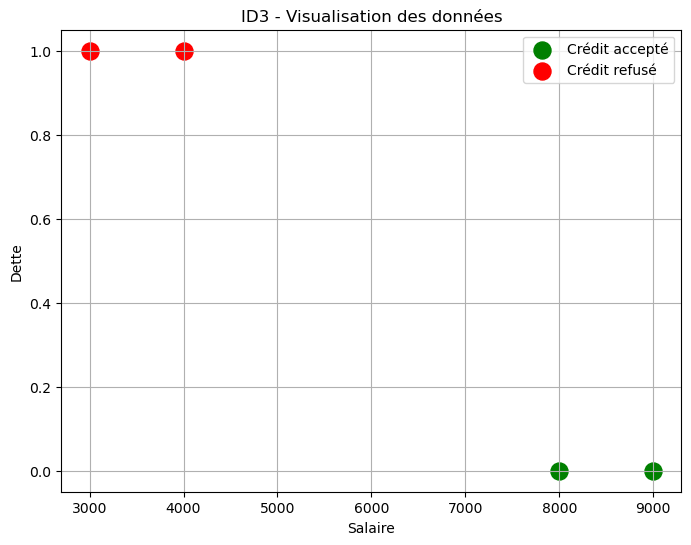

In [6]:
# ============================================================
#                     ID3 FROM SCRATCH
# ============================================================
#
# L'algorithme ID3 est un arbre de décision utilisé pour la classification.
#
# Il utilise :
#
# 1. Entropy
# 2. Information Gain
#
# Objectif :
# Trouver le meilleur split pour séparer les données.
#
# Situation :
# Une banque veut savoir si elle accepte un crédit ou non.
#
# Variables :
# X1 = salaire
# X2 = dette
#
# Résultat :
# 1 = accepté
# 0 = refusé
# ============================================================

import numpy as np


# ============================================================
# DONNÉES D'ENTRAÎNEMENT
# ============================================================
#
# Chaque ligne représente un client.
#
# [salaire, dette]
#
# dette :
# 0 = pas de dette
# 1 = dette
# ============================================================

X = np.array([[3000, 1],[8000, 0],[4000, 1],[9000, 0]])


# résultats attendus
#
# 1 = crédit accepté
# 0 = crédit refusé

y = np.array([

    0,
    1,
    0,
    1

])



# ============================================================
# CALCUL DE L’ENTROPY
# ============================================================
#
# L'entropy mesure le niveau de désordre dans les données.
#
# Si toutes les données appartiennent à la même classe :
#
# → entropy faible
#
# Si les classes sont mélangées :
#
# → entropy élevée
#
# Formule mathématique :
#
# Entropy = - Σ(p * log2(p))
#
# p = probabilité d’une classe
# ============================================================

def entropy(y):

    # récupération des classes et leurs nombres
    classes, counts = np.unique(

        y,
        return_counts=True

    )

    # calcul des probabilités
    probabilities = counts / counts.sum()

    # initialisation de l'entropy
    ent = 0

    # application de la formule
    for p in probabilities:

        ent -= p * np.log2(p)

    return ent



# ============================================================
# CALCUL DU GAIN D’INFORMATION
# ============================================================
#
# L’information gain permet de choisir le meilleur split.
#
# Formule :
#
# Gain = Entropy(parent) - Entropy(enfants)
#
# Plus le gain est grand :
#
# → meilleure séparation
# ============================================================

def information_gain(colonne, y, seuil):

    # séparation des données
    gauche = colonne <= seuil
    droite = colonne > seuil

    # éviter les groupes vides
    if len(y[gauche]) == 0 or len(y[droite]) == 0:

        return 0

    # entropy avant division
    entropy_parent = entropy(y)

    # taille totale
    n = len(y)

    # entropy du groupe gauche
    entropy_gauche = entropy(y[gauche])

    # entropy du groupe droite
    entropy_droite = entropy(y[droite])

    # moyenne pondérée des entropies
    entropy_enfants = (

        (len(y[gauche]) / n) * entropy_gauche +

        (len(y[droite]) / n) * entropy_droite

    )

    # calcul du gain
    gain = entropy_parent - entropy_enfants

    return gain



# ============================================================
# TEST DE L’ALGORITHME
# ============================================================
#
# On teste un seuil = 5000
#
# Question :
#
# salaire <= 5000 ?
#
# L’algorithme va calculer
# le gain d'information.
# ============================================================

gain = information_gain(

    X[:, 0],
    y,
    5000

)

print("Information Gain :", gain)

# ============================================================
# AFFICHAGE DU GRAPHE
# ============================================================
#
# Le graphe montre :
#
# Vert  → crédit accepté
# Rouge → crédit refusé
#
# Axe X → salaire
# Axe Y → dette
# ============================================================

import matplotlib.pyplot as plt


# clients acceptés
acceptes = X[y == 1]

# clients refusés
refuses = X[y == 0]


# taille de la figure
plt.figure(figsize=(8, 6))


# affichage des clients acceptés
plt.scatter(

    acceptes[:, 0],
    acceptes[:, 1],

    color='green',

    s=150,

    label='Crédit accepté'

)


# affichage des clients refusés
plt.scatter(

    refuses[:, 0],
    refuses[:, 1],

    color='red',

    s=150,

    label='Crédit refusé'

)


# titre
plt.title("ID3 - Visualisation des données")


# noms des axes
plt.xlabel("Salaire")
plt.ylabel("Dette")


# grille
plt.grid(True)


# légende
plt.legend()


# affichage final
plt.show()

Gain Ratio : 1.0


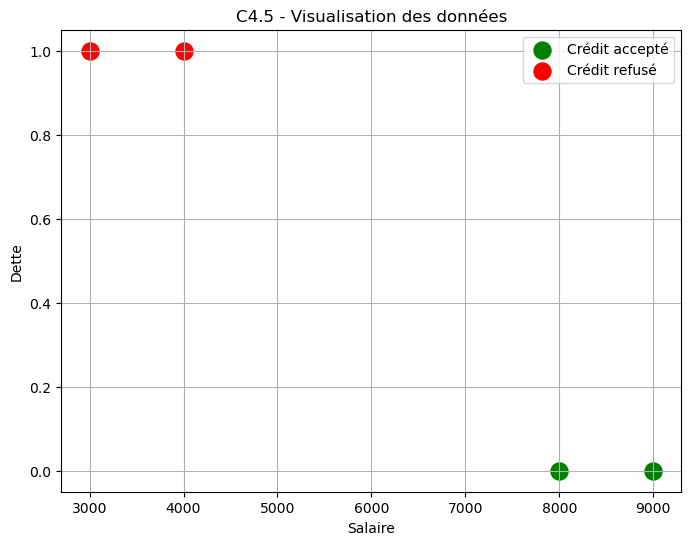

In [7]:
# ============================================================
#                    C4.5 FROM SCRATCH
# ============================================================
#
# C4.5 est une amélioration de ID3.
#
# Il utilise :
#
# 1. Entropy
# 2. Information Gain
# 3. Gain Ratio
#
# Le Gain Ratio permet d’éviter les mauvais splits.
#
# Situation :
# Une banque veut savoir si elle accepte un crédit ou non.
# ============================================================

import numpy as np


# ============================================================
# DONNÉES
# ============================================================
#
# [salaire, dette]
#
# dette :
# 0 = pas de dette
# 1 = dette
# ============================================================

X = np.array([

    [3000, 1],
    [8000, 0],
    [4000, 1],
    [9000, 0]

])


# résultats
#
# 1 = accepté
# 0 = refusé

y = np.array([

    0,
    1,
    0,
    1

])



# ============================================================
# CALCUL DE L’ENTROPY
# ============================================================
#
# L'entropy mesure le désordre dans les données.
#
# Formule : Entropy = - Σ(p * log2(p))
# ============================================================

def entropy(y):

    # récupération des classes
    classes, counts = np.unique(

        y,
        return_counts=True

    )

    # calcul des probabilités
    probabilities = counts / counts.sum()

    # initialisation
    ent = 0

    # application de la formule
    for p in probabilities:

        ent -= p * np.log2(p)

    return ent



# ============================================================
# CALCUL DE L’INFORMATION GAIN
# ============================================================
#
# Gain = Entropy(parent) - Entropy(enfants)
#
# Plus le gain est grand :
# → meilleure séparation
# ============================================================

def information_gain(colonne, y, seuil):

    # séparation des données
    gauche = colonne <= seuil
    droite = colonne > seuil

    # éviter les groupes vides
    if len(y[gauche]) == 0 or len(y[droite]) == 0:

        return 0

    # entropy avant split
    entropy_parent = entropy(y)

    # taille totale
    n = len(y)

    # entropy gauche
    entropy_gauche = entropy(y[gauche])

    # entropy droite
    entropy_droite = entropy(y[droite])

    # moyenne pondérée
    entropy_enfants = (

        (len(y[gauche]) / n) * entropy_gauche +

        (len(y[droite]) / n) * entropy_droite

    )

    # calcul du gain
    gain = entropy_parent - entropy_enfants

    return gain



# ============================================================
# CALCUL DU SPLIT INFORMATION
# ============================================================
#
# Split Information mesure la répartition des données.
#
# Formule :
#
# SplitInfo = - Σ(p * log2(p))
# ============================================================

def split_information(colonne, seuil):

    # séparation
    gauche = colonne <= seuil
    droite = colonne > seuil

    # taille totale
    n = len(colonne)

    # probabilités
    p_gauche = np.sum(gauche) / n
    p_droite = np.sum(droite) / n

    # initialisation
    split_info = 0

    # calcul
    for p in [p_gauche, p_droite]:

        if p > 0:

            split_info -= p * np.log2(p)

    return split_info



# ============================================================
# CALCUL DU GAIN RATIO
# ============================================================
#
# Formule :
#
# Gain Ratio = Information Gain / Split Information
#
# C4.5 choisit :
#
# → le plus grand Gain Ratio
# ============================================================

def gain_ratio(colonne, y, seuil):

    # calcul du gain
    gain = information_gain(

        colonne,
        y,
        seuil

    )

    # calcul split information
    split_info = split_information(

        colonne,
        seuil

    )

    # éviter division par zéro
    if split_info == 0:

        return 0

    # calcul final
    ratio = gain / split_info

    return ratio



# ============================================================
# TEST
# ============================================================
#
# Test avec seuil = 5000
#
# Question :
#
# salaire <= 5000 ?
# ============================================================

ratio = gain_ratio(

    X[:, 0],
    y,
    5000

)

print("Gain Ratio :", ratio)

# ============================================================
# AFFICHAGE DU GRAPHE
# ============================================================
#
# Le graphe montre :
#
# Vert  → crédit accepté
# Rouge → crédit refusé
#
# Axe X → salaire
# Axe Y → dette
# ============================================================

import matplotlib.pyplot as plt


# clients acceptés
acceptes = X[y == 1]

# clients refusés
refuses = X[y == 0]


# taille de la figure
plt.figure(figsize=(8, 6))


# affichage des clients acceptés
plt.scatter(

    acceptes[:, 0],
    acceptes[:, 1],

    color='green',

    s=150,

    label='Crédit accepté'

)


# affichage des clients refusés
plt.scatter(

    refuses[:, 0],
    refuses[:, 1],

    color='red',

    s=150,

    label='Crédit refusé'

)


# titre
plt.title("C4.5 - Visualisation des données")


# noms des axes
plt.xlabel("Salaire")
plt.ylabel("Dette")


# grille
plt.grid(True)


# légende
plt.legend()


# affichage final
plt.show()

Score Gini : 0.0


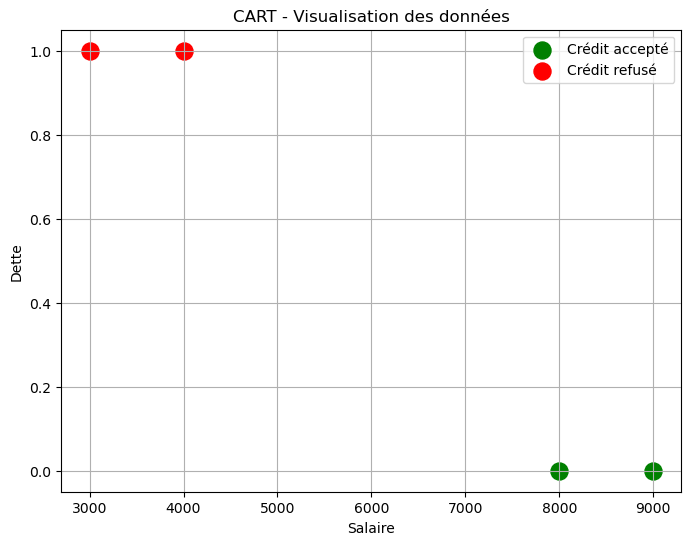

In [8]:
# ============================================================
#                    CART FROM SCRATCH
# ============================================================
#
# CART signifie :
#
# Classification And Regression Tree
#
# CART utilise :
#
# → Gini Index
#
# Contrairement à ID3 et C4.5 qui utilisent Entropy.
#
# CART cherche :
#
# → le plus petit Gini
# ============================================================

import numpy as np


# ============================================================
# DONNÉES
# ============================================================
#
# [salaire, dette]
#
# dette :
# 0 = pas de dette
# 1 = dette
# ============================================================

X = np.array([

    [3000, 1],
    [8000, 0],
    [4000, 1],
    [9000, 0]

])


# résultats
#
# 1 = accepté
# 0 = refusé

y = np.array([

    0,
    1,
    0,
    1

])



# ============================================================
# CALCUL DU GINI INDEX
# ============================================================
#
# Le Gini mesure l’impureté des données.
#
# Si les données sont pures :
#
# → Gini faible
#
# Si les classes sont mélangées :
#
# → Gini élevé
#
# Formule :
#
# Gini = 1 - Σ(p²)
# ============================================================

def gini(y):

    # récupération des classes
    classes, counts = np.unique(

        y,
        return_counts=True

    )

    # probabilités
    probabilities = counts / counts.sum()

    # initialisation
    gini_index = 1

    # application de la formule
    for p in probabilities:

        gini_index -= p ** 2

    return gini_index



# ============================================================
# CALCUL DU SCORE GINI
# ============================================================
#
# CART teste plusieurs splits
# puis choisit :
#
# → le plus petit score Gini
# ============================================================

def score_gini(colonne, y, seuil):

    # séparation
    gauche = colonne <= seuil
    droite = colonne > seuil

    # éviter groupes vides
    if len(y[gauche]) == 0 or len(y[droite]) == 0:

        return 999

    # taille totale
    n = len(y)

    # calcul gini gauche
    gini_gauche = gini(y[gauche])

    # calcul gini droite
    gini_droite = gini(y[droite])

    # moyenne pondérée
    score = (

        (len(y[gauche]) / n) * gini_gauche +

        (len(y[droite]) / n) * gini_droite

    )

    return score



# ============================================================
# TEST
# ============================================================
#
# Test avec seuil = 5000
#
# Question :
#
# salaire <= 5000 ?
# ============================================================

score = score_gini(

    X[:, 0],
    y,
    5000

)

print("Score Gini :", score)

# ============================================================
# AFFICHAGE DU GRAPHE
# ============================================================
#
# Le graphe montre :
#
# Vert  → crédit accepté
# Rouge → crédit refusé
#
# Axe X → salaire
# Axe Y → dette
# ============================================================

import matplotlib.pyplot as plt


# clients acceptés
acceptes = X[y == 1]

# clients refusés
refuses = X[y == 0]


# taille de la figure
plt.figure(figsize=(8, 6))


# affichage des clients acceptés
plt.scatter(

    acceptes[:, 0],
    acceptes[:, 1],

    color='green',

    s=150,

    label='Crédit accepté'

)


# affichage des clients refusés
plt.scatter(

    refuses[:, 0],
    refuses[:, 1],

    color='red',

    s=150,

    label='Crédit refusé'

)


# titre
plt.title("CART - Visualisation des données")


# noms des axes
plt.xlabel("Salaire")
plt.ylabel("Dette")


# grille
plt.grid(True)


# légende
plt.legend()


# affichage final
plt.show()